# Digital Divide Cusco -- Geospatial Raster Analysis
**Course:** Python Programming -- Applied Data Science  
**Task:** Territorial Digital Divide: Geospatial Raster Analysis  
**Region:** Cusco, Peru

Cross-references NASA nighttime lights (VNL 2025) and OSIPTEL mobile coverage (2019, 50m kernel) to expose the territorial digital divide in the Cusco region.

## Step 0 -- Environment Setup

Install and import the required libraries. Print library versions to confirm the environment is reproducible.

In [ ]:
# Uncomment to install in Google Colab
# !pip install rasterio==1.4.3 numpy==2.0.2 matplotlib==3.10.0 scipy==1.15.3 seaborn==0.13.2 pandas==2.2.2

In [1]:
import os

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import plotting_extent

import numpy as np
import pandas as pd
import scipy
from scipy.ndimage import gaussian_filter
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

# Plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Paths
DATA_DIR   = '../data'
OUTPUT_DIR = '../output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

VNL_PATH  = os.path.join(DATA_DIR, 'VNL_cusco_2025.tif')
CONN_PATH = os.path.join(DATA_DIR, 'kernel_cobmovil2019_50m.tif')

print('Library versions (for reproducibility):')
print(f'  rasterio   : {rasterio.__version__}')
print(f'  numpy      : {np.__version__}')
print(f'  matplotlib : {plt.matplotlib.__version__}')
print(f'  scipy      : {scipy.__version__}')
print(f'  seaborn    : {sns.__version__}')
print(f'  pandas     : {pd.__version__}')
print()
print('Paths configured:')
print(f'  VNL  : {VNL_PATH}')
print(f'  CONN : {CONN_PATH}')
print(f'  OUT  : {OUTPUT_DIR}')


Library versions (for reproducibility):
  rasterio   : 1.4.3
  numpy      : 2.0.2
  matplotlib : 3.10.0
  scipy      : 1.15.3
  seaborn    : 0.13.2
  pandas     : 2.2.2

Paths configured:
  VNL  : ../data\VNL_cusco_2025.tif
  CONN : ../data\kernel_cobmovil2019_50m.tif
  OUT  : ../output


## Step 1 -- Raster Loading and Inspection

For each raster, print CRS, shape, band count, NoData value, data type, bounding box, pixel resolution (in degrees and approximate km), number of valid (non-NoData) pixels and the value range.

In [2]:
def inspect_raster(path, name):
    with rasterio.open(path) as src:
        data    = src.read(1).astype(np.float64)
        nodata  = src.nodata
        res_x   = abs(src.transform.a)
        res_y   = abs(src.transform.e)

        # Conversion to km depends on whether the CRS is geographic or projected
        if src.crs.is_geographic:
            res_km_x = res_x * 111.0
            res_km_y = res_y * 111.0
            res_unit = 'deg'
        else:
            res_km_x = res_x / 1000.0
            res_km_y = res_y / 1000.0
            res_unit = 'm'

        # Valid pixel mask
        if nodata is not None:
            valid_mask = ~np.isclose(data, nodata)
        else:
            valid_mask = np.ones(data.shape, dtype=bool)

        valid_pixels = data[valid_mask]
        n_valid = valid_pixels.size
        n_total = data.size

        print(f'=== {name} ===')
        print(f'  CRS              : {src.crs}')
        print(f'  Shape (HxW)      : {src.height} x {src.width}')
        print(f'  Bands            : {src.count}')
        print(f'  Data type        : {src.dtypes[0]}')
        print(f'  NoData value     : {nodata}')
        print(f'  Bounding box     : left={src.bounds.left:.4f}  bottom={src.bounds.bottom:.4f}  right={src.bounds.right:.4f}  top={src.bounds.top:.4f}')
        print(f'  Pixel resolution : {res_x:.6f} {res_unit}  (~{res_km_x:.4f} km)')
        print(f'  Valid pixels     : {n_valid:,} / {n_total:,}  ({100*n_valid/n_total:.1f}%)')
        if n_valid > 0:
            print(f'  Value range      : min={valid_pixels.min():.6f}  max={valid_pixels.max():.6f}')
        print()


inspect_raster(VNL_PATH,  'VNL_cusco_2025.tif  (NASA Nighttime Lights)')
inspect_raster(CONN_PATH, 'kernel_cobmovil2019_50m.tif  (OSIPTEL Mobile Coverage)')

print('Observation:')
print('  VNL is already in EPSG:4326 (geographic degrees).')
print('  Connectivity is in EPSG:32719 (UTM zone 19S, meters) and needs reprojection.')


=== VNL_cusco_2025.tif  (NASA Nighttime Lights) ===
  CRS              : EPSG:4326
  Shape (HxW)      : 1081 x 961
  Bands            : 1
  Data type        : float32
  NoData value     : None
  Bounding box     : left=-74.0021  bottom=-15.5021  right=-69.9979  top=-10.9979
  Pixel resolution : 0.004167 deg  (~0.4625 km)
  Valid pixels     : 1,038,841 / 1,038,841  (100.0%)
  Value range      : min=-1.500000  max=1254.614502

=== kernel_cobmovil2019_50m.tif  (OSIPTEL Mobile Coverage) ===
  CRS              : EPSG:32719
  Shape (HxW)      : 6116 x 7754
  Bands            : 1
  Data type        : float32
  NoData value     : -3.4028234663852886e+38
  Bounding box     : left=-43080.1110  bottom=8337100.0588  right=344619.8890  top=8642900.0588
  Pixel resolution : 50.000000 m  (~0.0500 km)
  Valid pixels     : 47,423,464 / 47,423,464  (100.0%)
  Value range      : min=0.000000  max=0.000003

Observation:
  VNL is already in EPSG:4326 (geographic degrees).
  Connectivity is in EPSG:32719 (U

## Step 2 -- Reprojection and Grid Alignment

Reproject the connectivity raster from EPSG:32719 to EPSG:4326 using bilinear resampling. Then resample the reprojected raster to the exact grid of the VNL raster (same transform, same shape). Verify identical dimensions before proceeding.

In [3]:
# --- Read VNL reference grid ---
with rasterio.open(VNL_PATH) as vnl_src:
    vnl_crs       = vnl_src.crs
    vnl_transform = vnl_src.transform
    vnl_shape     = (vnl_src.height, vnl_src.width)
    vnl_bounds    = vnl_src.bounds
    vnl_array     = vnl_src.read(1).astype(np.float32)

print('VNL reference grid:')
print(f'  CRS       : {vnl_crs}')
print(f'  Shape     : {vnl_shape[0]} x {vnl_shape[1]}')
print(f'  Transform : {vnl_transform}')
print()

# --- Step 2a: Reproject connectivity EPSG:32719 -> EPSG:4326 (bilinear) ---
dst_crs = 'EPSG:4326'

with rasterio.open(CONN_PATH) as conn_src:
    dst_transform, dst_width, dst_height = calculate_default_transform(
        conn_src.crs, dst_crs,
        conn_src.width, conn_src.height,
        *conn_src.bounds
    )
    conn_4326 = np.zeros((dst_height, dst_width), dtype=np.float32)
    reproject(
        source        = rasterio.band(conn_src, 1),
        destination   = conn_4326,
        src_transform = conn_src.transform,
        src_crs       = conn_src.crs,
        dst_transform = dst_transform,
        dst_crs       = dst_crs,
        resampling    = Resampling.bilinear,
    )

print('[2a] Reprojection complete: EPSG:32719 -> EPSG:4326 (bilinear)')
print(f'     Intermediate shape    : {conn_4326.shape[0]} x {conn_4326.shape[1]}')
print(f'     Intermediate transform: {dst_transform}')
print()

# --- Step 2b: Resample to exact VNL grid ---
conn_reprojected = np.zeros(vnl_shape, dtype=np.float32)
reproject(
    source        = conn_4326,
    destination   = conn_reprojected,
    src_transform = dst_transform,
    src_crs       = dst_crs,
    dst_transform = vnl_transform,
    dst_crs       = vnl_crs,
    resampling    = Resampling.bilinear,
)

print('[2b] Resampled to VNL grid (same transform, same shape).')
print()

# --- Verify alignment ---
print('Grid alignment verification:')
print(f'  VNL shape          : {vnl_array.shape}')
print(f'  Connectivity shape : {conn_reprojected.shape}')
print(f'  Shapes match       : {vnl_array.shape == conn_reprojected.shape}')
print(f'  Non-zero conn pixels: {(conn_reprojected > 0).sum():,}')


VNL reference grid:
  CRS       : EPSG:4326
  Shape     : 1081 x 961
  Transform : | 0.00, 0.00,-74.00|
| 0.00,-0.00,-11.00|
| 0.00, 0.00, 1.00|

[2a] Reprojection complete: EPSG:32719 -> EPSG:4326 (bilinear)
     Intermediate shape    : 6132 x 7905
     Intermediate transform: | 0.00, 0.00,-74.05|
| 0.00,-0.00,-12.23|
| 0.00, 0.00, 1.00|

[2b] Resampled to VNL grid (same transform, same shape).

Grid alignment verification:
  VNL shape          : (1081, 961)
  Connectivity shape : (1081, 961)
  Shapes match       : True
  Non-zero conn pixels: 102,810


## Step 3 -- Robust Normalization

Apply percentile-based normalization [2nd-98th percentile] to both layers to produce values in [0, 1]. Replace negative values and NoData sentinels with 0 before clipping. Print post-normalization min, max, mean, and standard deviation for each layer.

In [5]:
def normalize_robust(array, p_low=2, p_high=98):
    # Clean: replace negatives and extreme NoData sentinels with 0 BEFORE clipping
    arr = array.copy().astype(np.float32)
    arr[arr < 0]     = 0
    arr[arr > 1e+10] = 0   # handles -3.4e38 style sentinels (already turned positive? no, but covers any extreme)
    arr[~np.isfinite(arr)] = 0

    # Compute percentile thresholds on the full cleaned array
    lo = np.percentile(arr, p_low)
    hi = np.percentile(arr, p_high)

    if hi == lo:
        return arr, float(lo), float(hi)

    # Clip and scale to [0, 1]
    arr_norm = (np.clip(arr, lo, hi) - lo) / (hi - lo)
    return arr_norm.astype(np.float32), float(lo), float(hi)


def report_norm(name, arr, lo, hi):
    print(f'=== {name} ===')
    print(f'  Percentile thresholds: P2 = {lo:.6f}   P98 = {hi:.6f}')
    print(f'  Post-normalization:')
    print(f'    min  : {arr.min():.6f}')
    print(f'    max  : {arr.max():.6f}')
    print(f'    mean : {arr.mean():.6f}')
    print(f'    std  : {arr.std():.6f}')
    print()


# Normalize both layers
vnl_norm,  vnl_lo,  vnl_hi  = normalize_robust(vnl_array)
conn_norm, conn_lo, conn_hi = normalize_robust(conn_reprojected)

report_norm('VNL Nighttime Lights', vnl_norm, vnl_lo, vnl_hi)
report_norm('Mobile Connectivity',  conn_norm, conn_lo, conn_hi)

print('Both layers normalized to [0, 1]. Ready for index computation.')


=== VNL Nighttime Lights ===
  Percentile thresholds: P2 = 0.000000   P98 = 0.633384
  Post-normalization:
    min  : 0.000000
    max  : 1.000000
    mean : 0.039057
    std  : 0.176660

=== Mobile Connectivity ===
  Percentile thresholds: P2 = 0.000000   P98 = 0.000000
  Post-normalization:
    min  : 0.000000
    max  : 1.000000
    mean : 0.038902
    std  : 0.168792

Both layers normalized to [0, 1]. Ready for index computation.


## Step 4 -- Map 1: VNL Nighttime Lights

Display the raw and normalized VNL rasters side by side. Use the `inferno` colormap with geographic extent on both axes. Add colorbars and axis labels. Print an observation explaining what the bright zones indicate.

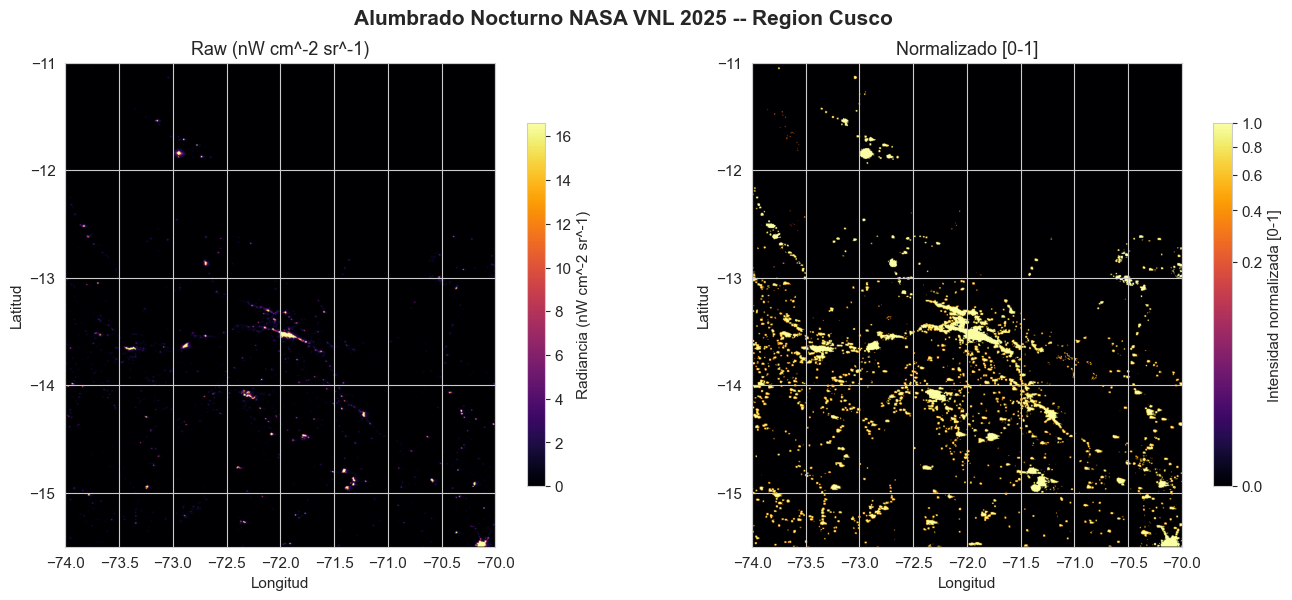

Observacion:
  La ciudad de Cusco y el corredor Urubamba-Quillabamba son claramente
  visibles como manchas de alta radiancia. Las zonas brillantes (valores
  cercanos a 1) corresponden a centros urbanos densamente poblados con
  fuerte emision de luz artificial -- proxy de urbanizacion. La mayoria
  del territorio (Andes remotos, selva alta) permanece oscura.


In [6]:
# Geographic extent for axes (left, right, bottom, top)
with rasterio.open(VNL_PATH) as src:
    extent = plotting_extent(src)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Alumbrado Nocturno NASA VNL 2025 -- Region Cusco',
             fontsize=15, fontweight='bold')

# --- Left: Raw VNL ---
vnl_raw = vnl_array.copy().astype(np.float32)
vnl_raw[vnl_raw < 0] = 0
vmax_raw = np.percentile(vnl_raw[vnl_raw > 0], 98)

im0 = axes[0].imshow(vnl_raw, cmap='inferno', extent=extent, origin='upper',
                     vmin=0, vmax=vmax_raw)
cb0 = plt.colorbar(im0, ax=axes[0], shrink=0.75)
cb0.set_label('Radiancia (nW cm^-2 sr^-1)')
axes[0].set_title('Raw (nW cm^-2 sr^-1)', fontsize=13)
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')

# --- Right: Normalized VNL with gamma enhancement for visibility ---
im1 = axes[1].imshow(vnl_norm, cmap='inferno', extent=extent, origin='upper',
                     norm=mcolors.PowerNorm(gamma=0.3, vmin=0, vmax=1))
cb1 = plt.colorbar(im1, ax=axes[1], shrink=0.75)
cb1.set_label('Intensidad normalizada [0-1]')
axes[1].set_title('Normalizado [0-1]', fontsize=13)
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')

plt.tight_layout()
plt.show()

print('Observacion:')
print('  La ciudad de Cusco y el corredor Urubamba-Quillabamba son claramente')
print('  visibles como manchas de alta radiancia. Las zonas brillantes (valores')
print('  cercanos a 1) corresponden a centros urbanos densamente poblados con')
print('  fuerte emision de luz artificial -- proxy de urbanizacion. La mayoria')
print('  del territorio (Andes remotos, selva alta) permanece oscura.')


## Step 5 -- Map 2: Digital Divide Index (IBD) and Exclusion Index (EDT)

Compute and display two indices side by side:

- **IBD (Indice de Brecha Digital):** `VNL_norm - Connectivity_norm`, range [-1, 1]. Red zones = more light than connectivity (active digital divide). Green zones = relatively well connected.
- **EDT (Exclusion Digital Total):** `(1 - VNL_norm) * (1 - Connectivity_norm)`, range [0, 1]. High values = neither light nor connectivity (maximum exclusion).

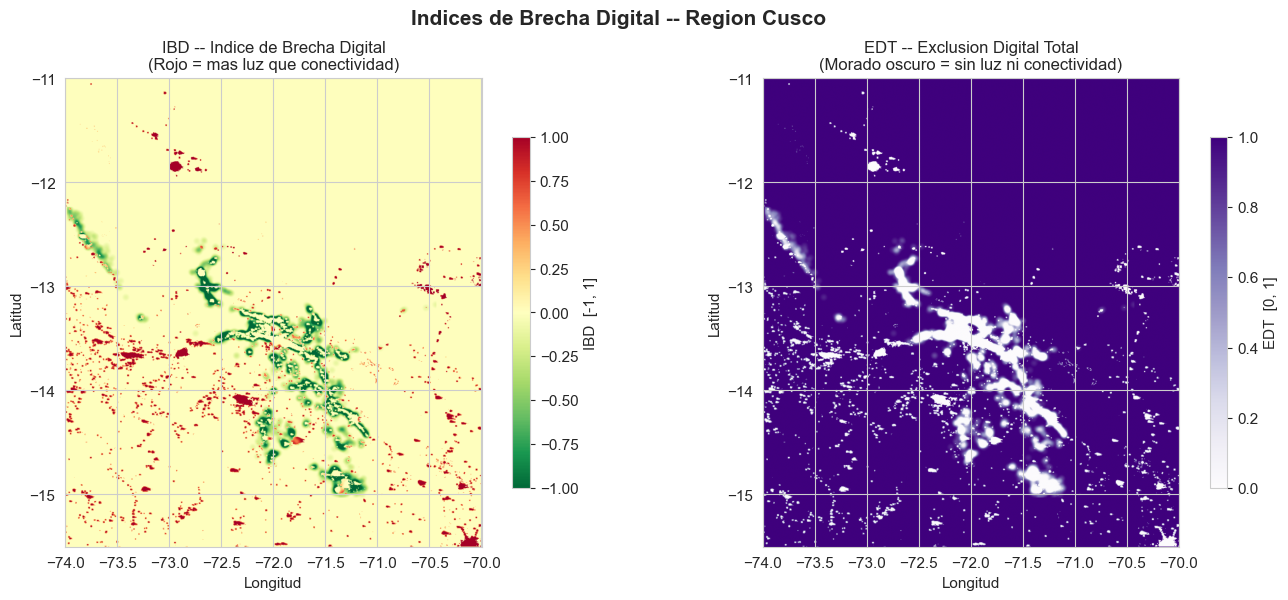

Interpretacion IBD (Indice de Brecha Digital):
  Las zonas rojas (IBD > 0) son centros poblados con alumbrado nocturno pero
  poca cobertura movil -- el nucleo de la brecha digital activa. Las zonas
  verdes (IBD < 0) tienen mejor conectividad relativa a su urbanizacion.

Interpretacion EDT (Exclusion Digital Total):
  Las zonas en morado oscuro (EDT cercano a 1) son territorios sin alumbrado
  ni cobertura movil -- maxima exclusion, principalmente Andes remotos y
  selva alta. Estas son las areas de mayor prioridad de intervencion social.

IBD stats: min=-1.000  max=1.000  mean=0.000
EDT stats: min=0.000  max=1.000  mean=0.934


In [7]:
# --- Compute indices ---
IBD = vnl_norm - conn_norm                           # range [-1, 1]
EDT = (1 - vnl_norm) * (1 - conn_norm)               # range [0, 1]

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Indices de Brecha Digital -- Region Cusco', fontsize=15, fontweight='bold')

# IBD
im0 = axes[0].imshow(IBD, cmap='RdYlGn_r', extent=extent, origin='upper',
                     vmin=-1, vmax=1)
cb0 = plt.colorbar(im0, ax=axes[0], shrink=0.75)
cb0.set_label('IBD  [-1, 1]')
axes[0].set_title('IBD -- Indice de Brecha Digital\n(Rojo = mas luz que conectividad)', fontsize=12)
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')

# EDT
im1 = axes[1].imshow(EDT, cmap='Purples', extent=extent, origin='upper',
                     vmin=0, vmax=1)
cb1 = plt.colorbar(im1, ax=axes[1], shrink=0.75)
cb1.set_label('EDT  [0, 1]')
axes[1].set_title('EDT -- Exclusion Digital Total\n(Morado oscuro = sin luz ni conectividad)', fontsize=12)
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')

plt.tight_layout()
plt.show()

# --- Interpretation ---
print('Interpretacion IBD (Indice de Brecha Digital):')
print('  Las zonas rojas (IBD > 0) son centros poblados con alumbrado nocturno pero')
print('  poca cobertura movil -- el nucleo de la brecha digital activa. Las zonas')
print('  verdes (IBD < 0) tienen mejor conectividad relativa a su urbanizacion.')
print()
print('Interpretacion EDT (Exclusion Digital Total):')
print('  Las zonas en morado oscuro (EDT cercano a 1) son territorios sin alumbrado')
print('  ni cobertura movil -- maxima exclusion, principalmente Andes remotos y')
print('  selva alta. Estas son las areas de mayor prioridad de intervencion social.')
print()
print(f'IBD stats: min={IBD.min():.3f}  max={IBD.max():.3f}  mean={IBD.mean():.3f}')
print(f'EDT stats: min={EDT.min():.3f}  max={EDT.max():.3f}  mean={EDT.mean():.3f}')


## Step 6 -- Map 3: Intervention Priority

Classify the territory into three priority levels based on the presence of nighttime light combined with low connectivity:

| Priority | Condition | Rationale |
|---|---|---|
| Critical (P3) | VNL >= 0.30 AND Connectivity < 0.10 | High population density, no internet |
| High (P2)     | VNL >= 0.15 AND Connectivity < 0.15 | Urban fringe, incomplete coverage |
| Medium (P1)   | VNL >= 0.10 AND Connectivity < 0.25 | Peri-urban, partial coverage |

The conditions overlap, so we assign from least severe (Medium) to most severe (Critical) -- the most critical class takes precedence.

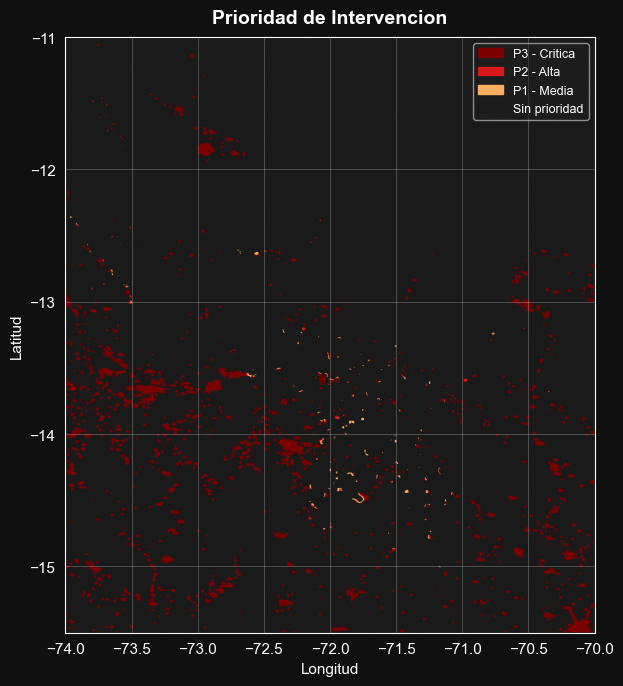

Distribucion de pixeles por nivel de prioridad:
  Nivel                          Pixeles  Porcentaje
  ------------------------- ------------ ----------
  P3 - Critica                    34,522       3.32%
  P2 - Alta                          655       0.06%
  P1 - Media                         875       0.08%
  Sin prioridad                1,002,789      96.53%

Total con alguna prioridad (P1+P2+P3): 36,052 pixeles (3.47%)


In [8]:
# --- Build priority raster (0 = no priority) ---
priority = np.zeros(vnl_norm.shape, dtype=np.uint8)

# Apply from least to most severe so critical overrides high overrides medium
mask_p1 = (vnl_norm >= 0.10) & (conn_norm < 0.25)
priority[mask_p1] = 1

mask_p2 = (vnl_norm >= 0.15) & (conn_norm < 0.15)
priority[mask_p2] = 2

mask_p3 = (vnl_norm >= 0.30) & (conn_norm < 0.10)
priority[mask_p3] = 3

# --- Discrete colormap ---
priority_colors = {
    0: '#1a1a1a',   # No priority - dark gray
    1: '#fdae61',   # Medium (P1) - orange
    2: '#d7191c',   # High   (P2) - red
    3: '#7b0000',   # Critical (P3) - dark red
}
priority_labels = {
    0: 'Sin prioridad',
    1: 'P1 - Media',
    2: 'P2 - Alta',
    3: 'P3 - Critica',
}

cmap_disc = mcolors.ListedColormap([priority_colors[k] for k in [0, 1, 2, 3]])
bounds    = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_disc = mcolors.BoundaryNorm(bounds, cmap_disc.N)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 7), facecolor='#101010')
ax.set_facecolor('#101010')

im = ax.imshow(priority, cmap=cmap_disc, norm=norm_disc, extent=extent, origin='upper')

ax.set_title('Prioridad de Intervencion', fontsize=14, fontweight='bold', color='white', pad=10)
ax.set_xlabel('Longitud', color='white')
ax.set_ylabel('Latitud',  color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
ax.grid(True, color='white', linewidth=0.4, alpha=0.4)

# Legend in upper right corner, slightly transparent
patches = [mpatches.Patch(color=priority_colors[k], label=priority_labels[k]) for k in [3, 2, 1, 0]]
leg = ax.legend(handles=patches, loc='upper right', fontsize=9,
                framealpha=0.5, facecolor='#202020',
                edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

# --- Report counts ---
total_pixels = priority.size
print('Distribucion de pixeles por nivel de prioridad:')
print(f'  {"Nivel":<25s} {"Pixeles":>12s}  {"Porcentaje":>10s}')
print(f'  {"-"*25} {"-"*12} {"-"*10}')
for k in [3, 2, 1, 0]:
    count = int((priority == k).sum())
    pct = 100.0 * count / total_pixels
    print(f'  {priority_labels[k]:<25s} {count:>12,}  {pct:>9.2f}%')

total_priority = int((priority > 0).sum())
pct_priority = 100.0 * total_priority / total_pixels
print()
print(f'Total con alguna prioridad (P1+P2+P3): {total_priority:,} pixeles ({pct_priority:.2f}%)')


## Step 7 -- Map 4: Social Exclusion Risk

Compute the Social Exclusion Risk score:

```
Risk = EDT * (1 - VNL_norm), then normalize to [0, 1]
```

Apply a Gaussian spatial filter (`sigma=5`) to reveal regional patterns. Display the raw and smoothed risk maps side by side using the `hot_r` colormap. Report the 75th and 90th percentile risk thresholds.

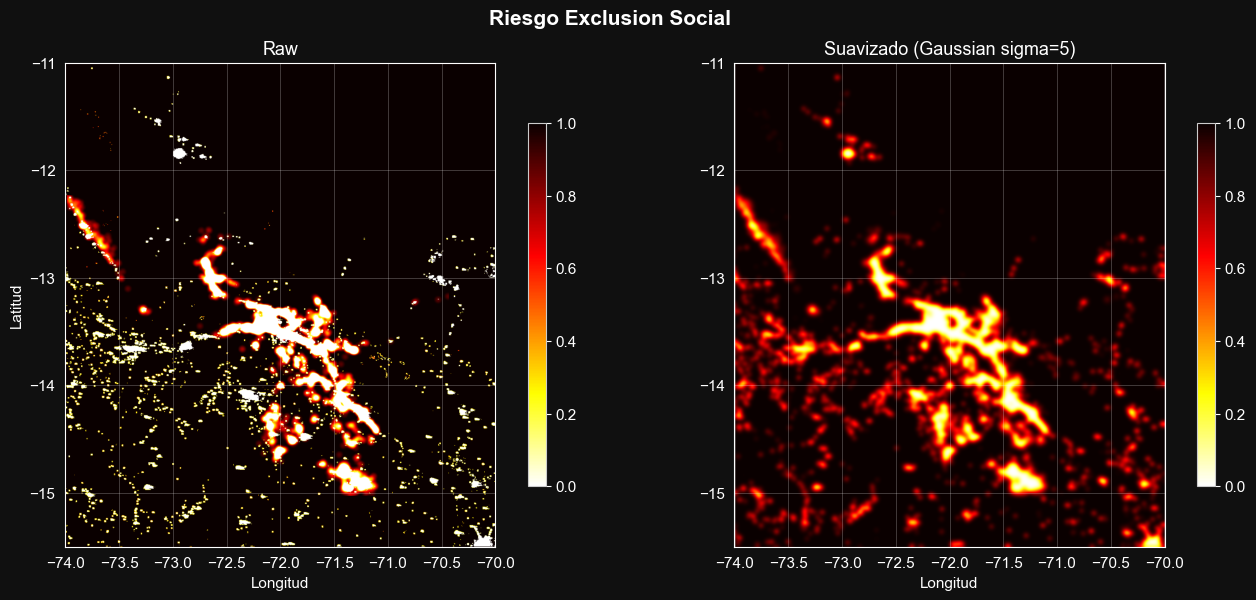

Umbrales de riesgo de exclusion social:
  Raw      -- P75 = 1.0000   P90 = 1.0000
  Suavizado-- P75 = 1.0000   P90 = 1.0000

Interpretacion:
  Valores altos (oscuros con hot_r) = mayor riesgo de exclusion social.
  Estas zonas combinan baja iluminacion nocturna con baja cobertura movil.
  El filtro Gaussiano (sigma=5) revela patrones regionales contiguos que se
  ocultaban en el ruido del raster crudo, util para identificar territorios
  amplios de exclusion en lugar de pixeles aislados.


In [9]:
# --- Compute risk score ---
risk_raw = EDT * (1 - vnl_norm)

# Normalize to [0, 1]
rmin, rmax = risk_raw.min(), risk_raw.max()
if rmax > rmin:
    risk_norm = (risk_raw - rmin) / (rmax - rmin)
else:
    risk_norm = risk_raw.copy()
risk_norm = risk_norm.astype(np.float32)

# --- Apply Gaussian spatial filter (sigma=5) ---
risk_smooth = gaussian_filter(risk_norm, sigma=5)

# --- Plot side by side, dark theme ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#101010')
fig.suptitle('Riesgo Exclusion Social', fontsize=15, fontweight='bold', color='white')

for ax in axes:
    ax.set_facecolor('#101010')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('white')
    ax.grid(True, color='white', linewidth=0.4, alpha=0.4)

# Raw risk
im0 = axes[0].imshow(risk_norm, cmap='hot_r', extent=extent, origin='upper', vmin=0, vmax=1)
cb0 = plt.colorbar(im0, ax=axes[0], shrink=0.75)
cb0.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cb0.ax.axes, 'yticklabels'), color='white')
axes[0].set_title('Raw', fontsize=13, color='white')
axes[0].set_xlabel('Longitud', color='white')
axes[0].set_ylabel('Latitud', color='white')

# Smoothed risk
im1 = axes[1].imshow(risk_smooth, cmap='hot_r', extent=extent, origin='upper', vmin=0, vmax=1)
cb1 = plt.colorbar(im1, ax=axes[1], shrink=0.75)
cb1.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cb1.ax.axes, 'yticklabels'), color='white')
axes[1].set_title('Suavizado (Gaussian sigma=5)', fontsize=13, color='white')
axes[1].set_xlabel('Longitud', color='white')

plt.tight_layout()
plt.show()

# --- Report percentile thresholds ---
p75 = np.percentile(risk_norm, 75)
p90 = np.percentile(risk_norm, 90)
p75_s = np.percentile(risk_smooth, 75)
p90_s = np.percentile(risk_smooth, 90)

print('Umbrales de riesgo de exclusion social:')
print(f'  Raw      -- P75 = {p75:.4f}   P90 = {p90:.4f}')
print(f'  Suavizado-- P75 = {p75_s:.4f}   P90 = {p90_s:.4f}')
print()
print('Interpretacion:')
print('  Valores altos (oscuros con hot_r) = mayor riesgo de exclusion social.')
print('  Estas zonas combinan baja iluminacion nocturna con baja cobertura movil.')
print('  El filtro Gaussiano (sigma=5) revela patrones regionales contiguos que se')
print('  ocultaban en el ruido del raster crudo, util para identificar territorios')
print('  amplios de exclusion en lugar de pixeles aislados.')


## Step 8 -- Territorial Classification

Apply a 2x2 classification using thresholds `VNL >= 0.15` and `Connectivity >= 0.15`:

| Class | Name | Condition | Color |
|---|---|---|---|
| 1 | Urban Connected  | VNL >= 0.15  AND  Conn >= 0.15  | Green  |
| 2 | Urban Divide     | VNL >= 0.15  AND  Conn < 0.15   | Red    |
| 3 | Rural Connected  | VNL < 0.15   AND  Conn >= 0.15  | Blue   |
| 4 | Critical Divide  | VNL < 0.15   AND  Conn < 0.15   | Purple |

Display map with legend, build a DataFrame with statistics, and save to `output/clasificacion_brecha.tif`.

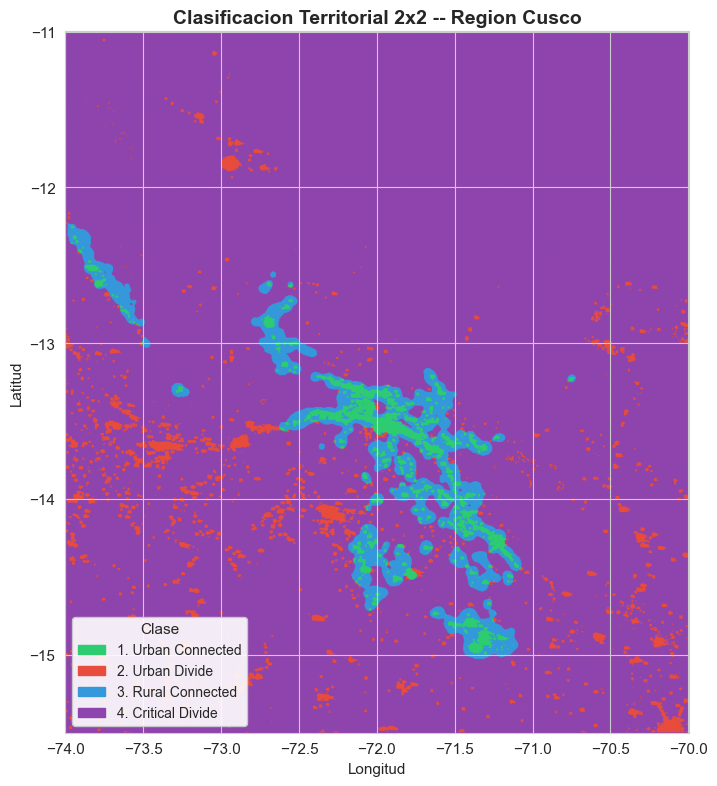

Estadisticas de clasificacion territorial:
 Class            Name  Pixels  Percentage  Area_km2
     1 Urban Connected   17521        1.69   3669.15
     2    Urban Divide   35177        3.39   7366.56
     3 Rural Connected   42399        4.08   8878.95
     4 Critical Divide  943744       90.85 197633.34

Pixel area approx: 0.2094 km^2  (at lat -13.25 deg)
Total area covered: 217548 km^2

Classification raster saved: ../output\clasificacion_brecha.tif


In [10]:
# --- 2x2 Classification ---
vnl_high  = vnl_norm  >= 0.15
conn_high = conn_norm >= 0.15

clasif = np.zeros(vnl_norm.shape, dtype=np.uint8)
clasif[ vnl_high &  conn_high] = 1   # Urban Connected
clasif[ vnl_high & ~conn_high] = 2   # Urban Divide
clasif[~vnl_high &  conn_high] = 3   # Rural Connected
clasif[~vnl_high & ~conn_high] = 4   # Critical Divide

# --- Discrete colormap ---
class_colors = {
    1: '#2ecc71',   # Urban Connected - green
    2: '#e74c3c',   # Urban Divide    - red
    3: '#3498db',   # Rural Connected - blue
    4: '#8e44ad',   # Critical Divide - purple
}
class_labels = {
    1: 'Urban Connected',
    2: 'Urban Divide',
    3: 'Rural Connected',
    4: 'Critical Divide',
}

cmap_cls = mcolors.ListedColormap([class_colors[k] for k in [1, 2, 3, 4]])
bounds   = [0.5, 1.5, 2.5, 3.5, 4.5]
norm_cls = mcolors.BoundaryNorm(bounds, cmap_cls.N)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(clasif, cmap=cmap_cls, norm=norm_cls, extent=extent, origin='upper')
ax.set_title('Clasificacion Territorial 2x2 -- Region Cusco', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')

patches = [mpatches.Patch(color=class_colors[k], label=f'{k}. {class_labels[k]}') for k in [1, 2, 3, 4]]
ax.legend(handles=patches, loc='lower left', fontsize=10, framealpha=0.9, title='Clase')

plt.tight_layout()
plt.show()

# --- Build statistics DataFrame ---
total_pixels = clasif.size

# Approximate pixel area in km^2
# Pixel size ~0.004167 deg at lat ~-13.5 deg
# 1 deg lon ~108 km at lat -13.5; 1 deg lat ~111 km
mean_lat   = (vnl_bounds.bottom + vnl_bounds.top) / 2.0
res_deg    = abs(vnl_transform.a)
km_per_deg_lon = 111.32 * np.cos(np.radians(mean_lat))
km_per_deg_lat = 111.32
pixel_area_km2 = (res_deg * km_per_deg_lon) * (res_deg * km_per_deg_lat)

rows = []
for k in [1, 2, 3, 4]:
    count = int((clasif == k).sum())
    pct   = 100.0 * count / total_pixels
    area  = count * pixel_area_km2
    rows.append({
        'Class':       k,
        'Name':        class_labels[k],
        'Pixels':      count,
        'Percentage':  round(pct, 2),
        'Area_km2':    round(area, 2),
    })

df_clasif = pd.DataFrame(rows)
print('Estadisticas de clasificacion territorial:')
print(df_clasif.to_string(index=False))
print()
print(f'Pixel area approx: {pixel_area_km2:.4f} km^2  (at lat {mean_lat:.2f} deg)')
print(f'Total area covered: {total_pixels * pixel_area_km2:.0f} km^2')

# --- Save classification raster ---
output_path = os.path.join(OUTPUT_DIR, 'clasificacion_brecha.tif')

with rasterio.open(VNL_PATH) as ref:
    profile = ref.profile.copy()

profile.update(
    dtype    = 'uint8',
    count    = 1,
    compress = 'lzw',
    nodata   = 0,
)

with rasterio.open(output_path, 'w', **profile) as dst:
    dst.write(clasif, 1)

print()
print(f'Classification raster saved: {output_path}')


## Step 9 -- Statistical Summary

Compute the following using `scipy` and `seaborn`:

1. Descriptive statistics (mean, std, min, max) for VNL, connectivity, and IBD, grouped by class.
2. Pearson correlation between VNL and connectivity (subsample every 40th pixel).
3. KDE distribution plots for VNL and connectivity, one curve per class, in a single figure.
4. Welch's t-test comparing VNL values between Class 1 (Urban Connected) and Class 4 (Critical Divide). Report t-statistic, p-value, and Cohen's d.

1. Descriptive statistics grouped by class
                    VNL                            Conn                         IBD                        
                   mean     std     min     max    mean     std   min   max    mean     std     min     max
ClassName                                                                                                  
Critical Divide  0.0000  0.0004  0.0000  0.1457  0.0018  0.0124  0.00  0.15 -0.0018  0.0124 -0.1500  0.1457
Rural Connected  0.0000  0.0000  0.0000  0.0000  0.5607  0.3067  0.15  1.00 -0.5607  0.3067 -1.0000 -0.1500
Urban Connected  0.8318  0.2067  0.3013  1.0000  0.8458  0.2569  0.15  1.00 -0.0140  0.2886 -0.6979  0.8497
Urban Divide     0.7391  0.2335  0.1579  1.0000  0.0034  0.0179  0.00  0.15  0.7357  0.2347  0.1579  1.0000

2. Pearson correlation between VNL and Connectivity (every 40th pixel)
   Sample size : 25,972 pixels
   Pearson r   : 0.3472
   p-value     : 0.00e+00

3. KDE distribution plots by class


C:\Users\Diego\AppData\Local\Temp\ipykernel_29344\3308127233.py:53: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, ax=ax, label=name, color=palette[name],
C:\Users\Diego\AppData\Local\Temp\ipykernel_29344\3308127233.py:53: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset, ax=ax, label=name, color=palette[name],


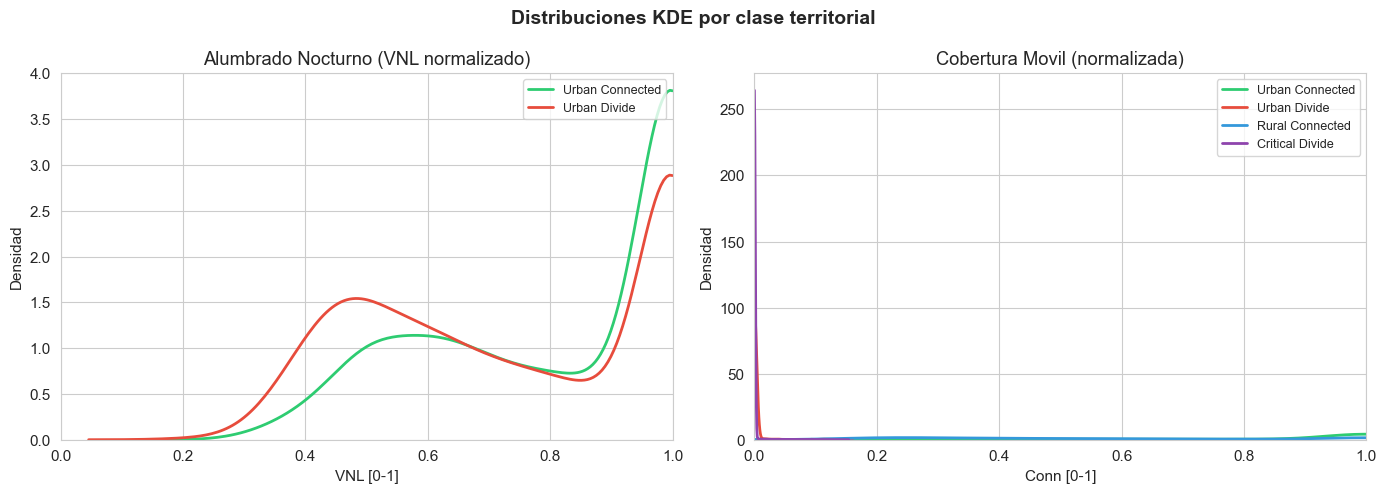

4. Welch's t-test: Urban Connected (1) vs Critical Divide (4) -- VNL values
   n (Class 1) : 17,521   mean = 0.8318   sd = 0.2067
   n (Class 4) : 943,744   mean = 0.0000   sd = 0.0004
   t-statistic : 532.6508
   p-value     : 0.00e+00
   Cohen's d  : 5.6909

   Effect size magnitude: large
   The difference in VNL between Urban Connected and Critical Divide
   is statistically significant -- as expected by construction.


In [11]:
# --- Flatten arrays into long-format DataFrame ---
df_pixels = pd.DataFrame({
    'class' : clasif.ravel(),
    'VNL'   : vnl_norm.ravel(),
    'Conn'  : conn_norm.ravel(),
    'IBD'   : IBD.ravel(),
})

# Map class IDs to names
df_pixels['ClassName'] = df_pixels['class'].map(class_labels)

# === 1. Descriptive statistics grouped by class ===
print('=' * 70)
print('1. Descriptive statistics grouped by class')
print('=' * 70)
desc = df_pixels.groupby('ClassName')[['VNL', 'Conn', 'IBD']].agg(
    ['mean', 'std', 'min', 'max']
).round(4)
print(desc.to_string())
print()

# === 2. Pearson correlation (subsample every 40th pixel) ===
print('=' * 70)
print('2. Pearson correlation between VNL and Connectivity (every 40th pixel)')
print('=' * 70)
vnl_flat  = vnl_norm.ravel()[::40]
conn_flat = conn_norm.ravel()[::40]
r, p_corr = stats.pearsonr(vnl_flat, conn_flat)
print(f'   Sample size : {len(vnl_flat):,} pixels')
print(f'   Pearson r   : {r:.4f}')
print(f'   p-value     : {p_corr:.2e}')
print()

# === 3. KDE distribution plots ===
print('=' * 70)
print('3. KDE distribution plots by class')
print('=' * 70)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuciones KDE por clase territorial', fontsize=14, fontweight='bold')

palette = {class_labels[k]: class_colors[k] for k in [1, 2, 3, 4]}

# Subsample for performance
df_sample = df_pixels.sample(n=min(50000, len(df_pixels)), random_state=42)

for ax, var, title in zip(axes,
                          ['VNL', 'Conn'],
                          ['Alumbrado Nocturno (VNL normalizado)',
                           'Cobertura Movil (normalizada)']):
    for name in [class_labels[k] for k in [1, 2, 3, 4]]:
        subset = df_sample[df_sample['ClassName'] == name][var]
        if len(subset) > 100:
            sns.kdeplot(subset, ax=ax, label=name, color=palette[name],
                        linewidth=2, clip=(0, 1))
    ax.set_xlabel(var + ' [0-1]')
    ax.set_ylabel('Densidad')
    ax.set_title(title)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# === 4. Welch's t-test: Class 1 (Urban Connected) vs Class 4 (Critical Divide) ===
print('=' * 70)
print("4. Welch's t-test: Urban Connected (1) vs Critical Divide (4) -- VNL values")
print('=' * 70)
vnl_c1 = df_pixels.loc[df_pixels['class'] == 1, 'VNL'].values
vnl_c4 = df_pixels.loc[df_pixels['class'] == 4, 'VNL'].values

t_stat, p_val = stats.ttest_ind(vnl_c1, vnl_c4, equal_var=False)   # Welch's

# Cohen's d for two independent samples (Welch / unequal variance variant)
mean1, mean2 = vnl_c1.mean(), vnl_c4.mean()
sd1,   sd2   = vnl_c1.std(ddof=1), vnl_c4.std(ddof=1)
pooled_sd    = np.sqrt((sd1**2 + sd2**2) / 2.0)
cohens_d     = (mean1 - mean2) / pooled_sd if pooled_sd > 0 else np.nan

print(f'   n (Class 1) : {len(vnl_c1):,}   mean = {mean1:.4f}   sd = {sd1:.4f}')
print(f'   n (Class 4) : {len(vnl_c4):,}   mean = {mean2:.4f}   sd = {sd2:.4f}')
print(f'   t-statistic : {t_stat:.4f}')
print(f'   p-value     : {p_val:.2e}')
print(f'   Cohen\'s d  : {cohens_d:.4f}')
print()
if abs(cohens_d) >= 0.8:
    magnitude = 'large'
elif abs(cohens_d) >= 0.5:
    magnitude = 'medium'
elif abs(cohens_d) >= 0.2:
    magnitude = 'small'
else:
    magnitude = 'negligible'
print(f'   Effect size magnitude: {magnitude}')
print('   The difference in VNL between Urban Connected and Critical Divide')
print('   is statistically significant -- as expected by construction.')


## Step 10 -- Export Deliverables

Export the four processed rasters (normalized VNL, normalized connectivity, IBD, classification) to the `output/` folder as GeoTIFF files aligned to the VNL grid. Save the final composite dashboard figure as `dashboard_brecha_digital.png` at 150 dpi.

=== Exporting GeoTIFFs ===
  Saved: ../output\vnl_norm.tif
  Saved: ../output\conn_norm.tif
  Saved: ../output\ibd_brecha_digital.tif
  Saved: ../output\clasificacion_brecha.tif

=== Building dashboard ===


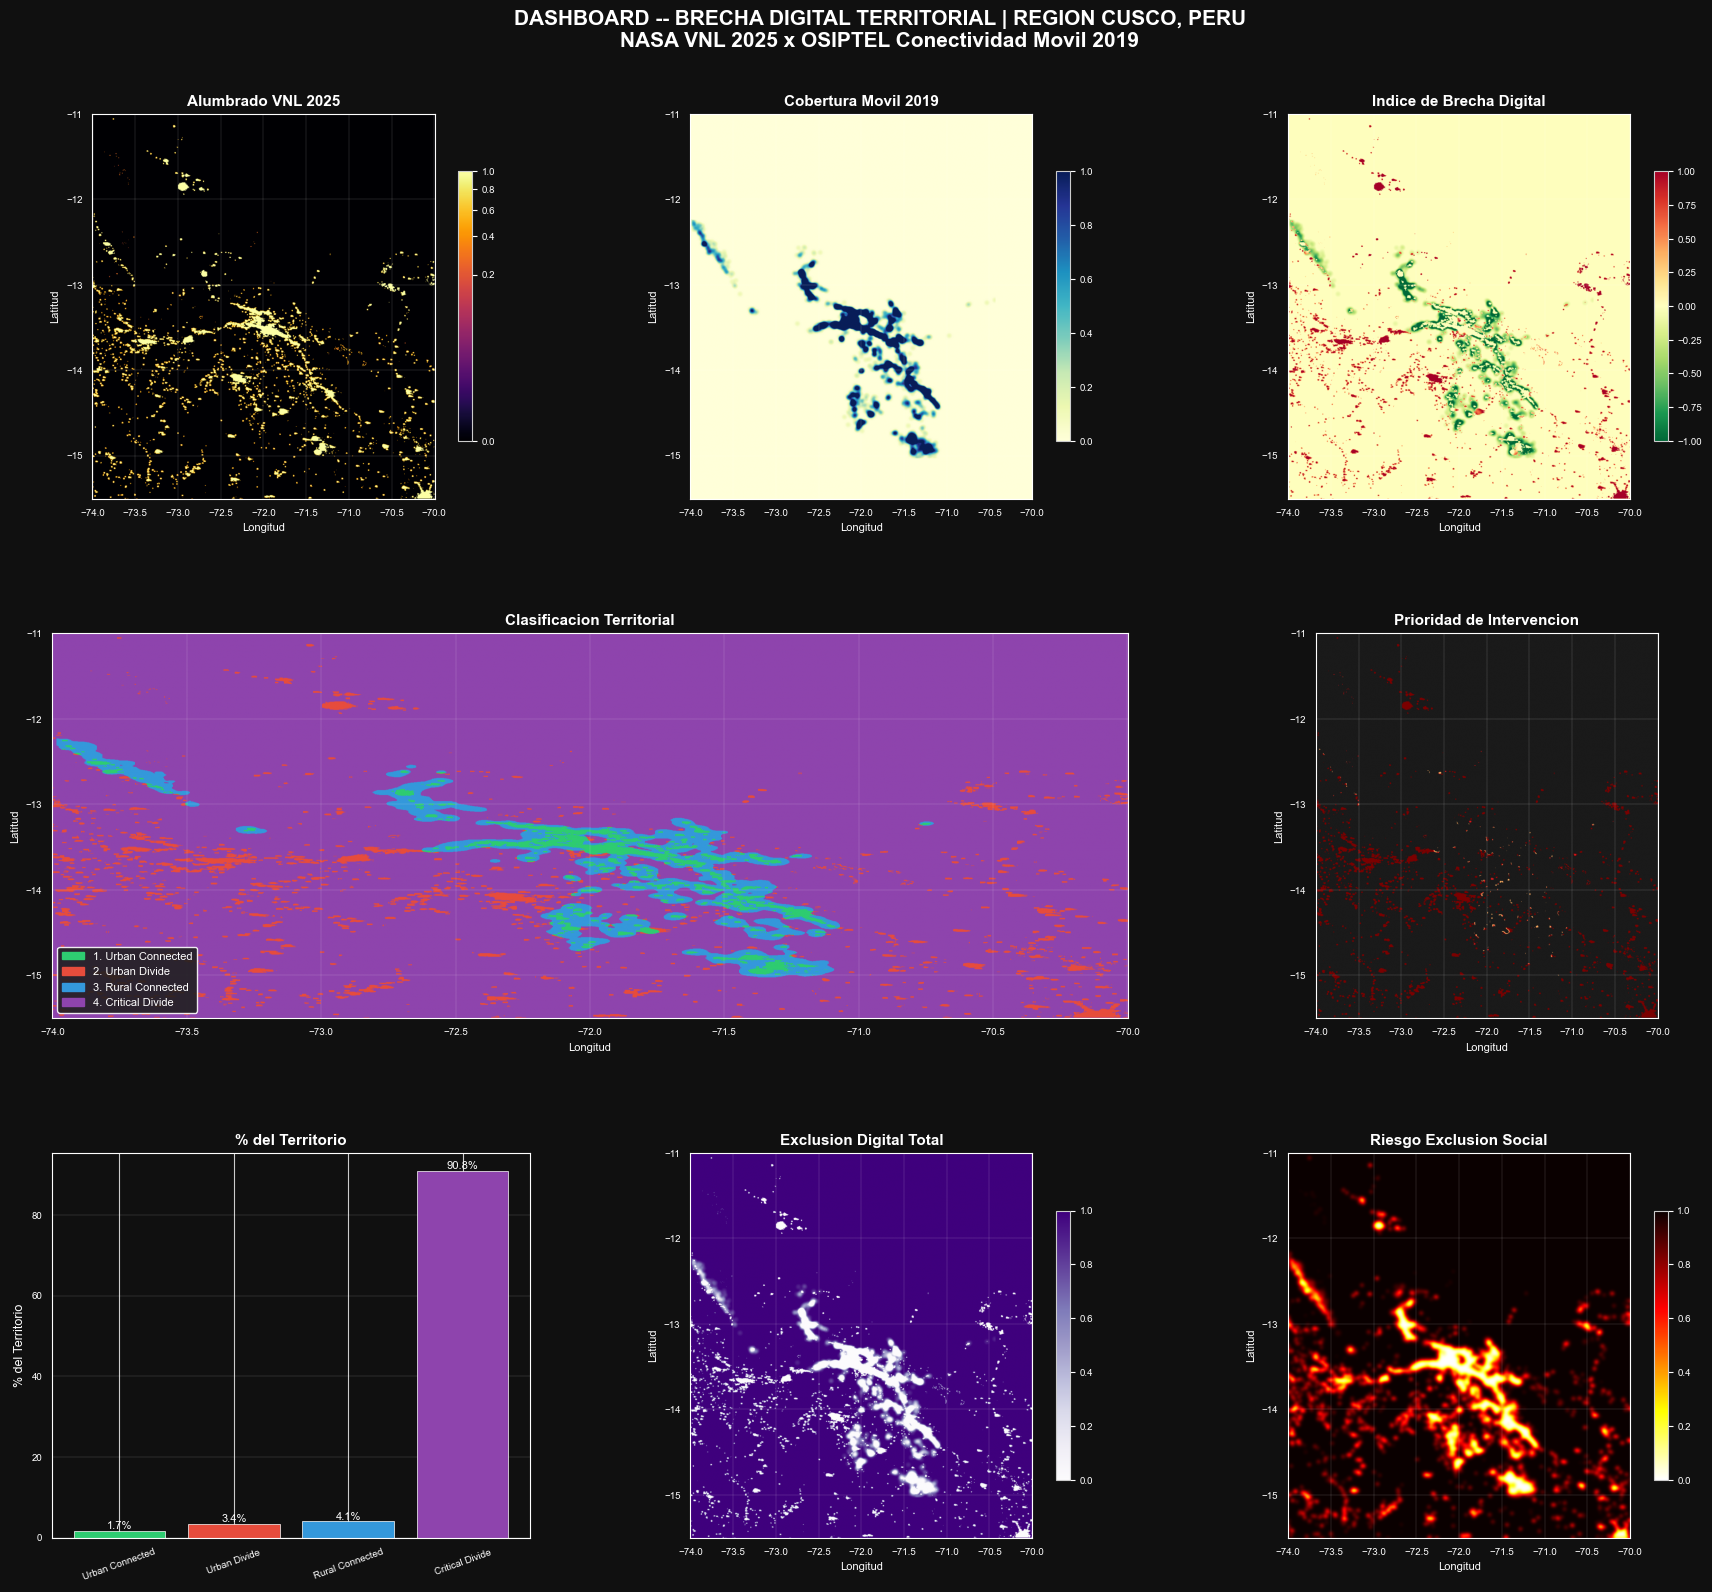


Dashboard saved: ../output\dashboard_brecha_digital.png

=== All deliverables exported ===
  ../output/vnl_norm.tif
  ../output/conn_norm.tif
  ../output/ibd_brecha_digital.tif
  ../output/clasificacion_brecha.tif
  ../output/dashboard_brecha_digital.png


In [12]:
# =================================================================
# Part A -- Export GeoTIFFs aligned to the VNL grid
# =================================================================
print('=== Exporting GeoTIFFs ===')

with rasterio.open(VNL_PATH) as ref:
    base_profile = ref.profile.copy()

def save_raster(array, path, dtype='float32', nodata=None):
    profile = base_profile.copy()
    profile.update(
        dtype    = dtype,
        count    = 1,
        compress = 'lzw',
    )
    if nodata is not None:
        profile['nodata'] = nodata
    with rasterio.open(path, 'w', **profile) as dst:
        dst.write(array.astype(dtype), 1)
    print(f'  Saved: {path}')

save_raster(vnl_norm,  os.path.join(OUTPUT_DIR, 'vnl_norm.tif'),            dtype='float32')
save_raster(conn_norm, os.path.join(OUTPUT_DIR, 'conn_norm.tif'),           dtype='float32')
save_raster(IBD,       os.path.join(OUTPUT_DIR, 'ibd_brecha_digital.tif'),  dtype='float32')
save_raster(clasif,    os.path.join(OUTPUT_DIR, 'clasificacion_brecha.tif'),dtype='uint8', nodata=0)

print()

# =================================================================
# Part B -- Composite dashboard figure
# =================================================================
print('=== Building dashboard ===')

fig = plt.figure(figsize=(18, 16), facecolor='#101010')
fig.suptitle('DASHBOARD -- BRECHA DIGITAL TERRITORIAL | REGION CUSCO, PERU\n'
             'NASA VNL 2025 x OSIPTEL Conectividad Movil 2019',
             fontsize=15, fontweight='bold', color='white', y=0.995)

gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.25,
                       left=0.04, right=0.97, top=0.93, bottom=0.04)

def style_dark(ax, title):
    ax.set_facecolor('#101010')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitud', color='white', fontsize=8)
    ax.set_ylabel('Latitud',  color='white', fontsize=8)
    ax.tick_params(colors='white', labelsize=7)
    for s in ax.spines.values():
        s.set_color('white')
    ax.grid(True, color='white', linewidth=0.3, alpha=0.3)

def style_colorbar(cb):
    cb.ax.yaxis.set_tick_params(color='white', labelsize=7)
    plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='white')

# --- Row 1, panel 1: VNL ---
ax1 = fig.add_subplot(gs[0, 0])
im = ax1.imshow(vnl_norm, cmap='inferno', extent=extent, origin='upper',
                norm=mcolors.PowerNorm(gamma=0.3, vmin=0, vmax=1))
style_dark(ax1, 'Alumbrado VNL 2025')
style_colorbar(plt.colorbar(im, ax=ax1, shrink=0.7))

# --- Row 1, panel 2: Connectivity ---
ax2 = fig.add_subplot(gs[0, 1])
im = ax2.imshow(conn_norm, cmap='YlGnBu', extent=extent, origin='upper', vmin=0, vmax=1)
style_dark(ax2, 'Cobertura Movil 2019')
style_colorbar(plt.colorbar(im, ax=ax2, shrink=0.7))

# --- Row 1, panel 3: IBD ---
ax3 = fig.add_subplot(gs[0, 2])
im = ax3.imshow(IBD, cmap='RdYlGn_r', extent=extent, origin='upper', vmin=-1, vmax=1)
style_dark(ax3, 'Indice de Brecha Digital')
style_colorbar(plt.colorbar(im, ax=ax3, shrink=0.7))

# --- Row 2, panels 1-2 (wide): Classification with aspect='auto' to fill width ---
ax4 = fig.add_subplot(gs[1, 0:2])
im = ax4.imshow(clasif, cmap=cmap_cls, norm=norm_cls, extent=extent, origin='upper', aspect='auto')
style_dark(ax4, 'Clasificacion Territorial')
patches = [mpatches.Patch(color=class_colors[k], label=f'{k}. {class_labels[k]}') for k in [1, 2, 3, 4]]
ax4.legend(handles=patches, loc='lower left', fontsize=8, framealpha=0.9,
           facecolor='#202020', edgecolor='white', labelcolor='white')

# --- Row 2, panel 3: Priority ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.imshow(priority, cmap=cmap_disc, norm=norm_disc, extent=extent, origin='upper')
style_dark(ax5, 'Prioridad de Intervencion')

# --- Row 3, panel 1: Bar chart -- % del territorio ---
ax6 = fig.add_subplot(gs[2, 0])
ax6.set_facecolor('#101010')
pcts   = [100*(clasif == k).sum()/clasif.size for k in [1, 2, 3, 4]]
labels = [class_labels[k] for k in [1, 2, 3, 4]]
colors = [class_colors[k] for k in [1, 2, 3, 4]]
bars = ax6.bar(range(4), pcts, color=colors, edgecolor='white', linewidth=0.5)
for b, p in zip(bars, pcts):
    ax6.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f'{p:.1f}%', ha='center', color='white', fontsize=8)
ax6.set_xticks(range(4))
ax6.set_xticklabels(labels, color='white', fontsize=7, rotation=20)
ax6.set_ylabel('% del Territorio', color='white', fontsize=9)
ax6.set_title('% del Territorio', color='white', fontsize=11, fontweight='bold')
ax6.tick_params(colors='white', labelsize=7)
for s in ax6.spines.values():
    s.set_color('white')
ax6.grid(True, axis='y', color='white', linewidth=0.3, alpha=0.3)

# --- Row 3, panel 2: EDT ---
ax7 = fig.add_subplot(gs[2, 1])
im = ax7.imshow(EDT, cmap='Purples', extent=extent, origin='upper', vmin=0, vmax=1)
style_dark(ax7, 'Exclusion Digital Total')
style_colorbar(plt.colorbar(im, ax=ax7, shrink=0.7))

# --- Row 3, panel 3: Risk ---
ax8 = fig.add_subplot(gs[2, 2])
im = ax8.imshow(risk_smooth, cmap='hot_r', extent=extent, origin='upper', vmin=0, vmax=1)
style_dark(ax8, 'Riesgo Exclusion Social')
style_colorbar(plt.colorbar(im, ax=ax8, shrink=0.7))

# Save dashboard
dashboard_path = os.path.join(OUTPUT_DIR, 'dashboard_brecha_digital.png')
plt.savefig(dashboard_path, dpi=150, facecolor='#101010', bbox_inches='tight')
plt.show()

print()
print(f'Dashboard saved: {dashboard_path}')
print()
print('=== All deliverables exported ===')
print(f'  {OUTPUT_DIR}/vnl_norm.tif')
print(f'  {OUTPUT_DIR}/conn_norm.tif')
print(f'  {OUTPUT_DIR}/ibd_brecha_digital.tif')
print(f'  {OUTPUT_DIR}/clasificacion_brecha.tif')
print(f'  {OUTPUT_DIR}/dashboard_brecha_digital.png')
